In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [33]:
df = pd.read_csv("tissue_dataset.csv")
X = df.drop(columns = ["target", "target_actual"])
y = df["target"]
lasso_rank = pd.read_csv("results/lasso_feature_ranking.csv")
mrmr_rank = pd.read_csv("results/mrmr_feature_ranking.csv")
rf_rank = pd.read_csv("results/rf_importances_ranking.csv")
mi_rank = pd.read_csv("results/mi_importances_ranking.csv")
xgb_rank = pd.read_csv("results/xgb_importances_ranking.csv")


In [34]:
#Cross Validation
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

In [35]:
#Feature Counts
feature_counts = [
    5, 10, 15, 20, 25, 30, 35, 40, 45, 50
]

In [36]:
#IFS loop for SVM
results = []

for k in feature_counts:
    selected_features = (
        mrmr_rank["miRNA"].head(k).tolist()
    )

    X_subset = X[selected_features]
    pipeline = Pipeline([
        (
            "smote", 
            SMOTE(random_state = 42)
        ),
        (
            "svm",
            SVC(
                kernel = "linear",
                random_state = 42
            )
        )
    ])

    scores = cross_val_score(
        pipeline,
        X_subset,
        y,
        cv = cv,
        scoring = "f1"
    )

    results.append([
        k, 
        scores.mean(),
        scores.std()
    ])
    ifs_results = pd.DataFrame(
        results,
        columns = [
            "Features",
            "Mean_F1",
            "Std_F1"
        ]
    )

ifs_results.to_csv(
    "results/ifs_results.csv",
    index=False
)
ifs_results

,Features,Mean_F1,Std_F1
0,5,0.979408,0.013188
1,10,0.987408,0.010286
2,15,0.987581,0.010145
3,20,0.991837,0.009998
4,25,0.995918,0.008163
5,30,0.995918,0.008163
6,35,0.995918,0.008163
7,40,0.995918,0.008163
8,45,0.995918,0.008163
9,50,0.995918,0.008163


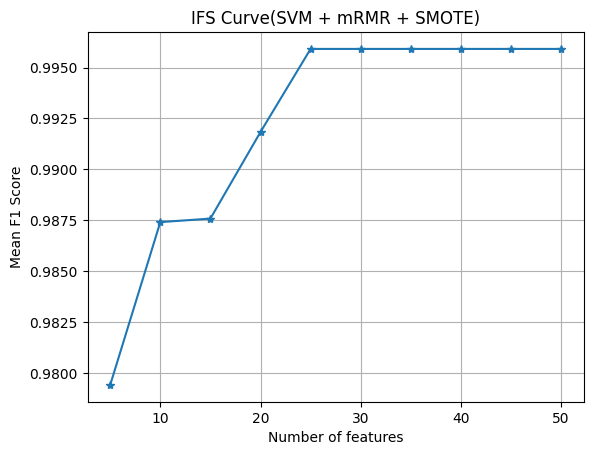

In [37]:
#IFS Curve
plt.plot(
    ifs_results["Features"],
    ifs_results["Mean_F1"],
    marker = "*"
)
plt.xlabel("Number of features")
plt.ylabel("Mean F1 Score")
plt.title("IFS Curve(SVM + mRMR + SMOTE)")
plt.grid(True)
plt.savefig(
    "figures/IFS_Curve",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [38]:
#High Confidence Biomarkers
optimal_panel = set(
    mrmr_rank.head(25)["miRNA"]
)

consensus_set = {
    "147709 : hsa-miR-3185",
    "168791 : hsa-miR-4785"
}

optimal_panel.intersection(consensus_set)

{'147709 : hsa-miR-3185', '168791 : hsa-miR-4785'}

In [43]:
#Final list of top 25 Biomarkers

lasso_set = set(lasso_rank["miRNA"])
rf_set = set(rf_rank.head(20)["miRNA"])
mi_set = set(mi_rank.head(20)["miRNA"])
xgb_set = set(xgb_rank.head(20)["miRNA"])
mrmr_set = set(mrmr_rank.head(20)["miRNA"])

all_sets = [
    lasso_set,
    rf_set,
    mi_set,
    xgb_set, 
    mrmr_set
]

counter = Counter()
for s in [lasso_set, rf_set, mi_set, xgb_set, mrmr_set]:
    counter.update(s)

top25_panel = mrmr_rank.head(25).copy()

top25_panel["Consensus_Score"] = (
    top25_panel["miRNA"]
    .map(counter)
)

top25_panel.to_csv(
    "results/optimal_25_miRNA_panel.csv",
    index=False
)
top25_panel

,Rank,miRNA,Consensus_Score
0,1,168626 : hsa-miR-4662a-5p,3
1,2,42902 : hsa-miR-185-5p,1
2,3,168829 : hsa-miR-4794,1
3,4,147709 : hsa-miR-3185,5
4,5,145677 : hsa-miR-139-5p,3
5,6,46361 : hsa-miR-1278,3
6,7,168791 : hsa-miR-4785,5
7,8,147997 : hsa-miR-3934,2
8,9,30787 : hsa-miR-125b-5p,2
9,10,42681 : hsa-miR-1307-3p,3


## Incremental Feature Selection (IFS) Summary

Incremental Feature Selection (IFS) was performed using the mRMR-ranked miRNA features to determine the optimal number of biomarkers required for cancer versus normal tissue classification. An SVM classifier combined with SMOTE and 5-fold stratified cross-validation was used to evaluate feature subsets of increasing size.

The mean F1 score improved steadily as additional features were incorporated, reaching a maximum value of **0.9959** with the top **25 miRNAs**. No further performance improvement was observed beyond 25 features, indicating that a 25-miRNA panel provides the optimal balance between predictive performance and model complexity.

Based on these results, the top 25 mRMR-ranked miRNAs were selected as the final candidate biomarker panel for subsequent validation and downstream analyses.
